<h1 style="text-align: center; font-family: Arial; font-weight: bold; color:green; font-size:36px;">Sentiment Analysis on Energy in the Republic Ireland and other European Countries</h1>
<p>
    Data are gathered through multiple Reddit Forums related to energy topics in Ireland using the authorized API, adhering to the website's policies and regulations.  
</p>

In [150]:
# Import Libraries
# API Requests
import requests
import json

#Accessing Environment Variables
import os

# Data Manipulation
import pandas as pd
import re

# Visualisation
import plotly.express as px

# Word processors
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from dotenv import load_dotenv
from wordcloud import WordCloud

#Word Cloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Model
from flair.models import TextClassifier

In [15]:
# Install nltk
#!pip install nltk

# Download stopwords and punkt
#nltk.download('punkt')
#nltk.download('stopwords')

#Install wordcloud
#!pip install wordcloud

In [16]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Credentials

Credentials for the Reddit API were stored in an environment variable, which was accessed using the dotenv library to generate an access token that will be used for authentication. This approach promotes security in handling sensitive credentials, which follows good coding practice. 

In [18]:
# Load environment variables
load_dotenv()

# Get required credentials 
CLIENT_ID = os.getenv('CLIENT_ID')
CLIENT_SECRET = os.getenv('CLIENT_SECRET')
USERNAME = os.getenv('REDDIT_USERNAME')
PASSWORD = os.getenv('REDDIT_PASSWORD')
USER_AGENT= os.getenv('REDDIT_USERAGENT')

# Check all variables are loaded
if CLIENT_ID and CLIENT_SECRET and USERNAME and PASSWORD:
    print('Credentials Loaded!')
else:
    print('Error loading credentials!')

Credentials Loaded!


### Get Access Token

Securely authenticate using OAuth2, credentials will used to process a request for an access token to the authorization server.

In [20]:
# Identify authentication method
data = {
    'grant_type': 'password',
    'username': USERNAME,
    'password': PASSWORD
}

# Authentication
auth = requests.auth.HTTPBasicAuth(CLIENT_ID, CLIENT_SECRET)

# Headers
headers = {'User-Agent': USER_AGENT}

# Get access token
res = requests.post('https://www.reddit.com/api/v1/access_token',
                    auth=auth, data=data, headers=headers)

# Check if response is valid
if res.status_code != 200:
    print("Token request failed:", res.text)
    exit()
else: 
    token = res.json()['access_token']
    print('Token request successful.')

Token request successful.


## Data Gathering

List of specific countries related energy related forums where a function will go through each and collect data.

In [22]:
# List of all Reddit posts related to energy in Ireland which will be used to extract data
IE_POST_ID =[
    '1g6t908/electricity_bill/',
    '1b3qqxh/electricity_bill/',
    '12yqhv8/can_someone_eli5_why_our_electricity_prices_are/',
    '1exjvob/very_high_electricity_bill/',
    '1cuw7de/insane_electricity_usage/',
    '1k29se6/rise_in_electricity_costs_amid_move_from_fossil/',
    '/1jvvhli/lovely_day_outside_for_65_of_our_electricity_to/',
    '/1gk49ps/blow_for_homeowners_with_solar_panels_as_electric/',
    '1dndzwv/best_energy_provider_to_go_with/',
    '/1h1s73w/irelands_data_centres_turning_to_fossil_fuels/',
    '1ac754l/anyone_with_electric_ireland/',
    '1j07rjd/sse_airtricity_to_hike_electricity_gas_prices/'
]

# List of comments for Germarny
DE_POST_ID=[
    'qmdxtt/people_of_germany_why_is_your_electricity_cost/',
    'hu6lf8/germany_hits_627_renewables_in_2024_electricity/',
    '18pxe9v/almost_52_of_germanys_gross_electricity/',
    '1d0ab3a/germany_now_has_so_much_solar_power_that_its/',
    '6aqft4/germany_just_smashed_an_energy_record_generating/'
]

# List of comments for Hungary
HU_POST_ID=[
    '1h52uty/electricity_bill/',
    '/edwfri/paks_nuclear_power_plant_the_first_and_only/',
    '/zoe29z/1400_kwh_electricity_usage_possible_in_one_month/'
]

### Collect Data using Reddit API

Process a GET request to Reddit API to collect data/comments from Reddit forums. Store results in a list and convert into a dataframe which will be processed for data cleaning, randomize selection of data to be included in the study. 

In [24]:
# Set headers
headers = {
    'Authorization': f'bearer {token}',
    'User-Agent': USER_AGENT
}

# Initialize variable to store all scraped data
sentiment_arr = []

# Create a function to store data
append_function = lambda a ,x, y: sentiment_arr.append({'country': a ,'source':x,'comment':str(y)})

# Initialize Regex Pattern to get comments within 'selftext' or 'body'
re_pattern=r'"(?:selftext|body)"\s*:\s*"((?:\\.|[^"\\])*)"'

def collect_data(country, POST_ID):
    # Go through all POST_IDs 
    for _id in POST_ID:
        try:
            # Join URL and POST_ID
            url = f'https://oauth.reddit.com/comments/{_id}'
            print(f'getting data from {url}')
    
            # API call
            response = requests.get(url, headers=headers)
    
            # Check for response if success (200)
            if response.status_code != 200:
                print("Failed to fetch comments:", response.text)
                exit()
            else: 
                pass
                
            # Retrieve all matching patterns
            matches = re.findall(re_pattern, json.dumps(response.json()))  

            # Loop through all scraped data and store
            for match in matches:
              append_function(country, _id, match)
                
        except Exception as e:
            print(f'Error retrieving data from {_id}, error details: {e}')

# Collect Data per Country
collect_data('Ireland', IE_POST_ID)
collect_data('Germany', DE_POST_ID)
collect_data('Hungary', HU_POST_ID)
print('Collecting data completed!')

getting data from https://oauth.reddit.com/comments/1g6t908/electricity_bill/
getting data from https://oauth.reddit.com/comments/1b3qqxh/electricity_bill/
getting data from https://oauth.reddit.com/comments/12yqhv8/can_someone_eli5_why_our_electricity_prices_are/
getting data from https://oauth.reddit.com/comments/1exjvob/very_high_electricity_bill/
getting data from https://oauth.reddit.com/comments/1cuw7de/insane_electricity_usage/
getting data from https://oauth.reddit.com/comments/1k29se6/rise_in_electricity_costs_amid_move_from_fossil/
getting data from https://oauth.reddit.com/comments//1jvvhli/lovely_day_outside_for_65_of_our_electricity_to/
getting data from https://oauth.reddit.com/comments//1gk49ps/blow_for_homeowners_with_solar_panels_as_electric/
getting data from https://oauth.reddit.com/comments/1dndzwv/best_energy_provider_to_go_with/
getting data from https://oauth.reddit.com/comments//1h1s73w/irelands_data_centres_turning_to_fossil_fuels/
getting data from https://oau

### Preprocessing data Before Data Cleaning
This step involves removing comments with fewer than 10 words to avoid deleted values and to get more informative content for analysis. Also, implemented randomized selection of comments to reduce sampling bias or avoid getting comments in the same post, ensuring more diverse data from different forums, which generalizes the dataset for analysis. Lastly, equal sampling per counter was employed to avoid imbalance, especially for Flair Analysis, where we need to compare sentiment results per country.

In [26]:
print('Randomly picking data per country.')

# Convert array to dataframe
sentiments_df = pd.DataFrame(sentiment_arr)

# Filter Comments that it should contain altleast 10 words
sentiments_df=sentiments_df.loc[sentiments_df['comment'].apply(lambda x: len(x.split()) > 10)]

# Randomize selection of data and limit by 500 comments per country 
sentiments_df = sentiments_df.groupby('country').sample(n=500, replace=True, random_state=42).reset_index()
print(sentiments_df.country.value_counts())

print('Process Completed!')

Randomly picking data per country.
country
Germany    500
Hungary    500
Ireland    500
Name: count, dtype: int64
Process Completed!


## Data Cleaning
This process involves the use of WordNetLemmatizer, converting words to base form, which helps to group words with similar terms-beneficial for processes like transforming to a bag of words. <br />

The next step involved creating a custom text processing function where URLs, special characters, and extra white spaces and converted to lowercase. Removing stop words can be toggled for flexibility since Flair NLP works on full-text context and not on sparse tokens.


In [28]:
# Assign Lemmatizer
lemmatizer = WordNetLemmatizer()

# Set stop words to English
stop_words = set(stopwords.words('english'))

# Create a function to check for characters only
def is_letter_only(word):
    for char in word:
        if not char.isalpha():
            return False
    return True

# Create a function to lemmmatize text
def lemmatize_text(text):
    text_cleaned = ' '.join(lemmatizer.lemmatize(word) for word in text.split() if is_letter_only(word) and word)
    return text_cleaned

# Create a consolidate function to clean string
def custom_preprocessor(text, process=''):
    #Remove URLS
    text = re.sub(r"http\S+|www\S+", "", text)
   
    # Remove special characters
    text = re.sub(r"[^\w\s]", "", text)
   
    # Normalize white spaces
    text = re.sub(r"\s+", " ", text).strip()
   
    #Set all characters to lowercase
    text=text.lower()

    # Check if process='all' -- all steps will be performed in case converting texts to a bag of words
    # This is isolated since the steps below are not necessary for flair analysis
    if process=='all':
        # Remove stop words
        words = word_tokenize(text)
        filtered_text = [word for word in words if word.lower() not in stop_words and word.isalnum()]
        text=lemmatize_text(" ".join(filtered_text))
    else:
        pass
    # Return processed text
    return text

# Test functions
print(f'test: \n\nbefore: {sentiments_df.iloc[2].comment} \n\nafter: {custom_preprocessor(sentiments_df.iloc[2].comment, process='all')}')

test: 

before: Germany is already phasing out both hard coal and lignite. Most coal plants will be closed by 2030 and the last will shut down in 2038. 

after: germany already phasing hard coal lignite coal plant closed last shut


## Transform to Bag of Words

In [30]:
# Use CountVectorizer
vectorizer=CountVectorizer(stop_words='english',
                        max_df = .1, # Ignore words that appear in more than 10% of the document - treat them as too common to be useful
                        max_features = 500) # Top 500 words

# Apply custom cleaning to each comment
cleaned_comments = sentiments_df['comment'].loc[sentiments_df.country == 'Ireland'].apply(custom_preprocessor, process='all')

# Fit transform Data for vectorizer
X = vectorizer.fit_transform(cleaned_comments)

# Get Feature names
feature_names = vectorizer.get_feature_names_out()

# Revert data back to dataframe
X_df = pd.DataFrame(X.toarray(), columns=feature_names)

X_df

,able,absolutely,action,actual,actually,added,adult,advice,affinity,afford,...,world,worse,worth,wouldnt,ye,yeah,yes,youd,youre,zero
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<hr />

## Latent Dirichlet Allocation (LDA)

This process will utilize LDA to identify or extract key topics present within the collected data.<br /><br />

Parameters:<br />
<b>n_components:</b> group data into n number of topics<br />
<b>random_state:</b> set seet for reproducibility<br />
<b>learning_method:</b> is set to 'batch', which will utilize all data in each iteration, making the model accurate.

In [32]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components = 10,
                                random_state = 123,
                                learning_method = 'batch')
lda_result_topics = lda.fit_transform(X_df)

In [33]:
lda.components_.shape

(10, 500)

### Extract Key Topics from the LDA Result

In [73]:
n_top_words = 5

for topic_idx, topic in enumerate(lda.components_):
    print("Topic %d:" % (topic_idx + 1))
    print(" ".join([feature_names[i]
                    for i in topic.argsort()\
                        [:-n_top_words - 1:-1]]))

Topic 1:
charge work price free electric
Topic 2:
reading water meter use wind
Topic 3:
meter gas unit government want
Topic 4:
time meter read power estimated
Topic 5:
company make government country investment
Topic 6:
day fuel high fossil build
Topic 7:
reading looking advice month pay
Topic 8:
power dont green use party
Topic 9:
rate battery month electric use
Topic 10:
country price going expensive kwh


Analyzing the results, the topics were generated based on 5 important words: <br />

1. Free charging and electric prices 
2. Renewable energy sources monitoring
3. Gas consumption policies
4. Estimated power consumption over time
5. Government and companies' investment
6. High consumption of fossil fuels
7. Looking for a piece of advice on monthly usage
8. Public's opinion on renewable energy policies
9. Battery storage & electricity use
10. Rising cost of energy per kWh

Topics generated by the model are related to energy consumption, policies, and pricing, providing an overview of the most important discussions on issues and sentiment related to energy consumption and costs.

### Extracting sentiments based on topic 4 - on estimated power consumption over time

In [106]:
ie_energy = lda_result_topics[:, 3].argsort()[::-1]

for iter_idx, comment_idx in enumerate(ie_energy[:5]):
    print('\n Energy Sentiment #%d:' % (iter_idx + 1))
    print(custom_preprocessor(sentiments_df['comment'][comment_idx]))


 Energy Sentiment #1:
because electricity here is more reliable greener and climatefriendliernn power outages occur for 12 minutes per year for each customer in germany on average compared to 250 minutes in the us a big reason for that is that power here is more often underground than in the us which makes it more reliable but also more expensivenn 505 of electricity in germany is coming from renewable sources compared to 198 in the us germany started to subsidize solar power very early when it was still expensive with the goal to bring the production capacity and innovation up and make solar cheaper without this early investment solar power would not have become so cheap so fast a lot of solar panels all around the world would not have been installed in the last few years without this early investment and we are still paying for that and benefiting from it today see this vox podcast how germany helped make renewable energy cheap for the rest of the world the installed solar capacity 

<hr />

### Generate Word Cloud Based on the Top Words

A word cloud is a helpful tool to visualize frequently used words, offering quick insights into trending topics regarding energy.

In [163]:
# Get sum of occurrences per word
word_counts = X_df.sum(axis=0) # Convert sparse matrix to array
vocab=feature_names

# Transform to a dataframe and sort values from highest to lowest
word_freq = pd.DataFrame({'word': vocab, 'count': word_counts})
top_words = word_freq.sort_values(by='count', ascending=False)

# Show top 10 words
top_words.head(10)

,word,count
reading,reading,64
meter,meter,64
power,power,61
price,price,58
gas,gas,55
need,need,50
month,month,50
pay,pay,49
going,going,46
time,time,43


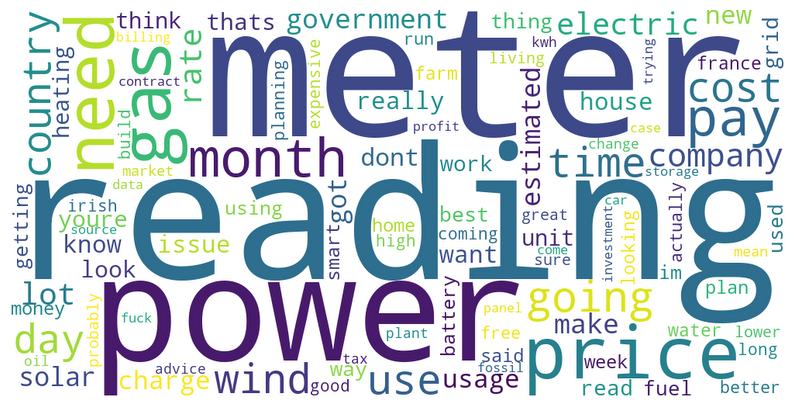

In [198]:
# Generate Word Cloud

# Create a dictionary of word and count
word_freq_dict = dict(zip(top_words['word'], top_words['count']))

# Generate word cloud
wc = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',  
    max_words=100  # show only top 100 frequent words
).generate_from_frequencies(word_freq_dict)

# Display
plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation='lanczos')
plt.axis('off')
plt.savefig('./assets/word_cloud.png',dpi=300, bbox_inches='tight') 
plt.show()

<hr />

## Sentiment Analysis using Flair NLP

Flair is a pre-trained language and contextual embedding-based model that focuses on sentiment analysis, which performs better at a deeper understanding of sentence structures, thus providing more accurate predictions than Vader (Soshace, 2023). 

In [132]:
# Clean data necessary for Flair
sentiments_df['cleaned']=sentiments_df.comment.apply(custom_preprocessor)

In [134]:
# Install Flair
# !pip install flair

In [136]:
# Load text classifier in english
classifier = TextClassifier.load('en-sentiment')

# Import Flair Sentence to process input text
from flair.data import Sentence

# Import accuracy_score to check performance
from sklearn.metrics import accuracy_score

In [137]:
# Create function to check score and provide equivalent sentiment
def format_output_flair(sentence):
    label = sentence.labels[0]
    if label.value == 'POSITIVE' and label.score > 0.7:
        return("Positive")
    elif label.value == 'NEGATIVE' and label.score > 0.7:
        return("Negative")
    else:
        return("Neutral")

# Create a function to analyze text sentiment using Flair
def analyze_flair(text):
    sentence = Sentence(text)
    classifier.predict(sentence)
    score = sentence.labels[0].score
    value = format_output_flair(sentence)
    return score, value

In [138]:
# Analyze data and store it in the dataframe
sentiments_df['flair_score'], sentiments_df['flair_prediction'] = zip(*sentiments_df['cleaned'].apply(analyze_flair))
sentiments_df.head(5)

,index,country,source,comment,cleaned,flair_score,flair_prediction
0,1240,Germany,qmdxtt/people_of_germany_why_is_your_electrici...,It includes taxes and EEG (officially for gree...,it includes taxes and eeg officially for green...,0.940817,Negative
1,1661,Germany,1d0ab3a/germany_now_has_so_much_solar_power_th...,Spot price for electricity . This does not inc...,spot price for electricity this does not inclu...,0.527261,Neutral
2,1443,Germany,18pxe9v/almost_52_of_germanys_gross_electricity/,Germany is already phasing out both hard coal ...,germany is already phasing out both hard coal ...,0.940034,Negative
3,1244,Germany,qmdxtt/people_of_germany_why_is_your_electrici...,Basically the same reason our petrol prices ar...,basically the same reason our petrol prices ar...,0.999974,Negative
4,1205,Germany,qmdxtt/people_of_germany_why_is_your_electrici...,It's pretty close. They put a tax on electrici...,its pretty close they put a tax on electricity...,0.830136,Negative


## Plot results 

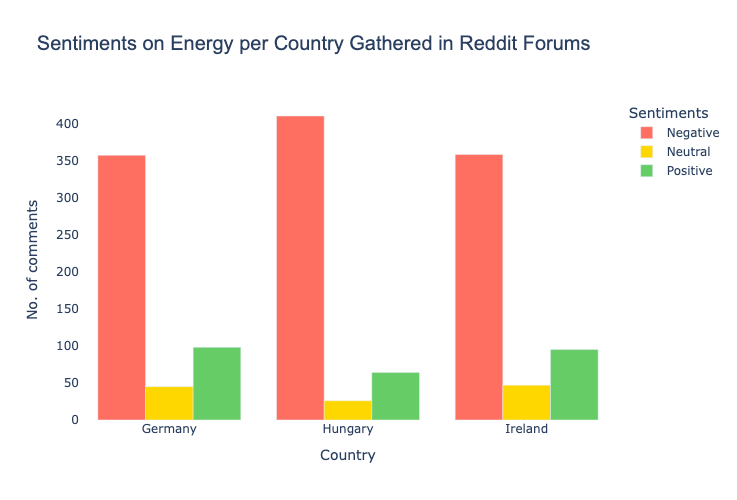

In [145]:
# Define color map
color_map = {
    'Positive': '#66CC66',
    'Negative': '#FF6F61',
    'Neutral': '#FFD700'
}

grouped_df = sentiments_df.groupby(['country', 'flair_prediction']).size().reset_index(name='count')


# Project Results
fig = px.bar(
    grouped_df,
    x='country', 
    y='count', 
    color='flair_prediction',
    color_discrete_map=color_map,
    labels={
        'count': 'No. of comments',
        'flair_prediction': 'Sentiments',
        'country': 'Country'
    },
    title='Sentiments on Energy per Country Gathered in Reddit Forums',
    barmode='group'
)


fig.update_layout(
    title_font=dict(size=20, family='Arial'),
    width=900,
    height=500,
    plot_bgcolor='rgba(0,0,0,0)' # this makes background transparent
)
#fig.write_html("assets/Sentiments_plot.html")
fig.write_image("assets/sentiment_analysis_plot.png") 
fig.show()

The results indicate that all three countries–Ireland, Germany, and Hungary show a high negative sentiment on energy-related topics. However, this is typical in this type of social media site like Reddit, where people can vent out their frustrations without any consequences (Rösner and Krämer, 2016). Interestingly, despite having one of the cheapest electricity rates in Europe, Hungary still has the highest negative comment count. This shows that users have high levels of dissatisfaction not only in regards to the cost but also other factors such as policies, service reliability, and other energy-related issues, which may be addressed by the government or the service providers.

# References


Pandey, P. (2023) The power of NLP with Flair: A comprehensive guide and comparison with other libraries. Medium. Available at: https://medium.com/@pankaj_pandey/the-power-of-nlp-with-flair-a-comprehensive-guide-and-comparison-with-other-libraries-d99875595396 (Accessed: 25 April 2025).

Akbik, A., Bergmann, T., Blythe, D., Rasul, K., Schweter, S. and Vollgraf, R. (2019) FLAIR: An easy-to-use framework for state-of-the-art NLP. Available at: https://github.com/flairNLP/flair (Accessed: 25 April 2025).

Reddit Inc. (2025) 'Reddit API'. Available at: https://www.reddit.com/dev/api (Accessed 13 May 2025).

Meredith W., n.d. WordClouds with Python. [online] Medium. Available at: https://medium.com/@m3redithw/wordclouds-with-python-c287887acc8b [Accessed 14 May 2025].

FlairNLP, (n.d.) Flair NLP Documentation. Available at: https://flairnlp.github.io/docs/intro (Accessed: 15 May 2025).

Soshace (2023) Unsupervised Sentiment Analysis using VADER and Flair. Available at: https://soshace.com/2023/04/15/unsupervised-sentiment-analysis-using-vader-and-flair/ (Accessed: 15 May 2025).
